# **🛩️ ATAS**

The **ATAS** (Aerial Threat Assessment System) is an end-to-end machine learning engineering project that combines
- computer vision,
- structured machine learning,
- tactical scenario generation,
- and interactive visualization into a single pipeline.

**The project is divided into three major components:**
- Aircraft Classification Model
- ETA Regressor Model
- Hit Classification Model

---

#### **In this notebook**

# **Aircraft Classification Model - v2**

This notebook upgrades the aircraft classifier to **EfficientNetV2-L**, pretrained on ImageNet21k and trained at **480×480** resolution on Kaggle (P100, 16GB VRAM).

---

### **Why v2?**

v1 used **MobileNetV2 at 224×224** and plateaued at **64.56% val accuracy**, a hard ceiling from model capacity and resolution, not from the data.

v2 addresses this directly:

| Upgrade | v1 | v2 |
|---|---|---|
| Model | MobileNetV2 | EfficientNetV2-L |
| Resolution | 224×224 | 480×480 |
| Augmentation | No | Yes |
| Class balancing | No | Yes |
| Platform | Local (4GB VRAM) | Kaggle P100 (16GB) |

---

**Target: 80%+ val accuracy across 101 aircraft classes.**

## **1. Problem Definition**

Given an image of a military aircraft, can a deep learning computer vision model (multi-class classification neural network) correctly classify the aircraft into its respective category?

---

## **2. Dataset**

The dataset used in this project contains military aircraft images across 101 aircraft categories and is being taken from [Military Aircraft Detection Dataset on Kaggle](https://www.kaggle.com/datasets/a2015003713/militaryaircraftdetectiondataset/data).

The dataset includes:
- fighter jets,
- bombers,
- helicopters,
- transport aircraft,
- UAVs,
- and reconnaissance aircraft.

Images contain variations in:
- aircraft angles,
- lighting conditions,
- backgrounds,
- scales,
- and image quality.

For this notebook, the `crop/` portion of the dataset will be used since it already contains aircraft images organized by class labels, making it suitable for multi-class image classification tasks.

The dataset was originally designed for fine-grained military aircraft recognition, where some visually similar aircraft variants are grouped into the same class due to minimal external differences.

<details>
<summary>View all 101 aircraft classes</summary>

`A10, A400M, AG600, AH64, AKINCI, AV8B, An124, An22, An225, An72, B1, B2, B21, B52, Be200, C1, C130, C17, C2, C390, C5, CH47, CH53, CL415, E2, E7, EF2000, EMB314, F117, F14, F15, F16, F18, F2, F22, F35, F4, FCK1, H6, Il76, J10, J20, J35, J36, J50, JAS39, JF17, JH7, KAAN, KC135, KF21, KIZILELMA, KJ600, Ka27, Ka52, MQ20, MQ25, MQ28, MQ9, Mi24, Mi26, Mi28, Mi8, Mig29, Mig31, Mirage2000, NH90, P3, RQ4, Rafale, SR71, Su24, Su25, Su34, Su47, Su57, T50, TB001, TB2, Tejas, Tornado, Tu160, Tu22M, Tu95, U2, UH60, US2, V22, V280, Vulcan, WZ10, WZ7, WZ9, X29, X32, XB70, XQ58, Y20, YF23, Z10, Z19`

</details>

---

## **3. Evaluation**

The goal is to correctly classify a military aircraft image into one of 101 categories.

The model will be considered performing well if it achieves **above 80% classification accuracy** on the validation set.

Additional indicators we will track:
- training & validation loss curves (to detect overfitting),
- confusion matrix (to see which aircraft classes the model confuses with each other),
- per-class prediction confidence,
- and visual inspection of sample predictions.

---

## **4. Features**

Some information about the data:

* We are dealing with images (unstructured data) so we will be using deep learning / transfer learning.
* There are `101` categories of military aircraft (101 different classes).
* The `crop/` folder contains `41,441` total cropped aircraft images organized by class label.
* Each class has its own subfolder inside `crop/` - the folder name is the label.
* The `labels_with_split.csv` file contains bounding box annotations and a predefined split column:
  - ~31k training annotations
  - ~7.5k validation annotations
  - ~2.7k test annotations

* Note: This CSV was designed for object detection. For our classifier we use the `crop/` folder directly, but will use the `split` column to respect the original train/validation/test separation.
* Images vary in angle, lighting, background, and scale, making this a fine-grained classification problem.
* Some visually similar aircraft variants are grouped into the same class due to minimal external differences.

## **5. Preparing the Tools**

We will be using the following libraries for this project:
- **NumPy**: numerical operations
- **Pandas**:  data manipulation and loading labels
- **Matplotlib**:  visualizing images and training curves
- **TensorFlow / Keras**: building and training the deep learning model
- **TensorFlow Hub**: loading the pretrained EfficientNetV2-L feature extractor
- **Scikit-learn**: evaluation metrics and class weight computation
- **OS / Pathlib**: navigating file paths and loading images from disk

In [1]:
# Pin to Keras 2 (tf_keras) — required for TF Hub KerasLayer compatibility
# Model was trained and saved using tf_keras; this flag ensures consistent
# loading across Kaggle and local environments
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import os
import logging

# ── Silence TF C++ backend ───────────────────────────────────────────────────
# TF's core is written in C++ and logs a lot of setup noise by default.
# Level 3 = show ERROR only. (0=all, 1=info, 2=warning, 3=error)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# ── Silence oneDNN ───────────────────────────────────────────────────────────
# oneDNN is Intel's deep learning kernel library - TF uses it internally.
# Disabling its logs stops messages like "oneDNN custom operations are on"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# ── Silence gRPC + glog ──────────────────────────────────────────────────────
# gRPC is TF's internal communication layer (used even in single-machine training).
# glog is Google's C++ logging library underneath it.
os.environ["GRPC_VERBOSITY"] = "ERROR"
os.environ["GLOG_minloglevel"] = "3"

import tensorflow as tf

# ── Silence TF Python-level logger ───────────────────────────────────────────
# Some warnings surface through TF's Python API rather than the C++ backend.
# These two lines catch those - both point to the same logger, belt-and-suspenders.
tf.get_logger().setLevel("ERROR")
logging.getLogger("tensorflow").setLevel(logging.ERROR)

<details>
<summary>ℹ️ Suppressing TensorFlow Logs</summary>

TensorFlow is verbose by default before training even starts, it logs dozens of
messages about hardware setup, internal libraries, and GPU configuration. Most of
these are not errors, just noise.

These logs come from **four different sources**, each needing its own silencer:

| Source | What it is | How we silence it |
|---|---|---|
| TF C++ backend | TF's core is written in C++ and logs setup info | `TF_CPP_MIN_LOG_LEVEL = 3` |
| oneDNN | Intel's deep learning kernel library, used internally by TF | `TF_ENABLE_ONEDNN_OPTS = 0` |
| gRPC / glog | TF's internal communication layer and Google's C++ logger | `GRPC_VERBOSITY`, `GLOG_minloglevel` |
| TF Python logger | Warnings that surface through TF's Python API | `tf.get_logger().setLevel("ERROR")` |

All four are set **before importing TensorFlow** where possible once TF loads,
some environment variables are already read and can no longer be changed.

After this block, only genuine errors will surface.

</details>

In [3]:
# Generates a current timestamp in IST -> used for naming saved models and predictions.
import datetime , pytz
ist = pytz.timezone("Asia/Kolkata")
datetime.datetime.now(ist).strftime("%Y-%m-%d_%H-%M-%S")

'2026-05-20_23-18-17'

In [4]:
# Importing the required tools

import os
import datetime
import pytz
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight  # class imbalance handling

import tensorflow as tf
import tensorflow_hub as hub  # pretrained EfficientNetV2-L
from tensorflow import keras  # type: ignore

# print("TensorFlow Version:", tf.__version__)
# print("TensorFlow Hub Version:", hub.__version__)
# print("NumPy Version:", np.__version__)
# print("Pandas Version:", pd.__version__)
# print("Keras Version:", keras.__version__)

pd.set_option('display.max_columns', None)

### **Environment & Path Configuration**

This section configures project paths and automatically detects whether the notebook is running **locally** or in **Google Colab**.

In [5]:
import os
from pathlib import Path

# Set to:
# - "auto"   -> detect the runtime
# - "colab"  -> force Google Colab
# - "kaggle" -> force Kaggle
# - "local"  -> force local machine
FORCE_ENV = "auto"


def detect_env():
    if os.path.exists("/kaggle"):
        return "kaggle"
    if "COLAB_GPU" in os.environ or os.path.exists("/content/drive"):
        return "colab"
    return "local"


ENV = detect_env() if FORCE_ENV == "auto" else FORCE_ENV
NOTEBOOK_DIR = Path.cwd().resolve()

if ENV == "colab":
    from google.colab import drive

    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/ATAS_Project")
    DATA_ROOT = PROJECT_ROOT / "data"
elif ENV == "kaggle":
    PROJECT_ROOT = Path("/kaggle/working")
    DATA_ROOT = Path("/kaggle/input/datasets/eakempreetsingh/atas-aircraft-dataset")
    if not DATA_ROOT.exists():
        DATA_ROOT = PROJECT_ROOT / "data"
else:
    PROJECT_ROOT = Path.cwd().resolve().parent.parent
    DATA_ROOT = PROJECT_ROOT / "data"

LOG_DIR = PROJECT_ROOT / "logs"
MODEL_DIR = PROJECT_ROOT / "models"
RELEASE_MODELS_DIR = PROJECT_ROOT / "release_models"
PREDICTIONS_DIR = PROJECT_ROOT / "predictions"
CROP_DIR = DATA_ROOT / "crop"
IMAGE_LABELS_CSV = DATA_ROOT / "image_with_labels.csv"
SPLITS_CSV = DATA_ROOT / "labels_with_split.csv"

# Create the folders this notebook writes to.
# Kaggle input directories are read-only, so only working/output folders are created.
for folder_path in [PROJECT_ROOT, DATA_ROOT, LOG_DIR, MODEL_DIR, RELEASE_MODELS_DIR, PREDICTIONS_DIR]:
    if ENV == "kaggle" and str(folder_path).startswith("/kaggle/input"):
        continue
    os.makedirs(folder_path, exist_ok=True)

print(f"ENV:               {ENV}")
print(f"NOTEBOOK_DIR:      {NOTEBOOK_DIR}")
print(f"PROJECT_ROOT:      {PROJECT_ROOT}")
print(f"DATA_ROOT:         {DATA_ROOT}")
print(f"CROP_DIR:          {CROP_DIR}")
print(f"LOG_DIR:           {LOG_DIR}")
print(f"MODEL_DIR:         {MODEL_DIR}")
print(f"RELEASE_MODELS_DIR:{RELEASE_MODELS_DIR}")
print(f"PREDICTIONS_DIR:   {PREDICTIONS_DIR}")
print(f"CROP_DIR exists:   {CROP_DIR.exists()}")
print(f"Classes found:     {len(list(CROP_DIR.glob('*'))) if CROP_DIR.exists() else 0}")
if not CROP_DIR.exists():
    print(f"[WARN] CROP_DIR not found: {CROP_DIR}")

ENV:               local
NOTEBOOK_DIR:      /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/notebooks/01_aircraft_classifier
PROJECT_ROOT:      /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project
DATA_ROOT:         /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data
CROP_DIR:          /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data/crop
LOG_DIR:           /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/logs
MODEL_DIR:         /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/models
RELEASE_MODELS_DIR:/mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/release_models
PREDICTIONS_DIR:   /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/predictions
CROP_DIR exists:   True
Classes found:     101


In [6]:
# tells TF to grow VRAM usage gradually instead of grabbing everything at once.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

## **6. Load Images**

We will load images from the `crop/` folder of the dataset.
Each subfolder inside `crop/` represents one aircraft class and contains cropped images of that aircraft.

Steps:
1. Count total images and classes ✅
2. Load file paths and labels from CSV ✅
3. Reconstruct absolute paths (environment-safe) ✅
4. Split into train / val / test ✅
5. Verify the data loaded correctly ✅

In [7]:
# Check folders and total images in it 

# Different class folders
classes_folder = sorted(os.listdir(CROP_DIR))

# Total images
total_images = sum(len(os.listdir(CROP_DIR / cls)) for cls in classes_folder)

print(f"Total classes: {len(classes_folder)}")
print(f"Total images: {total_images}")

Total classes: 101
Total images: 41441


In [8]:
# Load CSV and reconstruct absolute paths - works on local, Kaggle, and Colab
aircraft_labels = pd.read_csv(DATA_ROOT / "image_with_labels.csv")

# Reconstruct absolute paths from CROP_DIR + label + filename
aircraft_labels["filepath"] = aircraft_labels.apply(
    lambda row: str(CROP_DIR / row["label"] / Path(row["filepath"]).name), axis=1
)

print(aircraft_labels.shape)
aircraft_labels.head()

(41441, 3)


,filepath,label,split
0,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10,train
1,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10,train
2,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10,train
3,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10,train
4,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10,train


### **Why This Approach**

The CSV was built in `01_aircraft_classifier.ipynb` (v1) with file paths, labels, 
and a predefined train/val/test split. Rather than rebuilding it from scratch, 
v2 reuses it directly.

**The only change:** filepaths in the CSV are relative (`../data/crop/...`) and break 
outside the local environment. So we reconstruct absolute paths at load time using 
`CROP_DIR`, which is already set correctly per environment.

This keeps the notebook portable - same CSV, same split, works on local, Kaggle, and Colab.
To reproduce the CSV from scratch, follow the data preparation steps in `01_aircraft_classifier.ipynb`.


In [9]:
aircraft_labels.split.value_counts()

split
train         31127
validation     7545
test           2769
Name: count, dtype: int64

In [10]:
# Split the dataframe into training, validation and testing datasets

# Training dataframe
train_data_df = aircraft_labels[aircraft_labels["split"] == "train"].drop(columns="split")
train_data_df.reset_index(drop=True, inplace=True)

# Validation dataframe
val_data_df = aircraft_labels[aircraft_labels["split"] == "validation"].drop(columns="split")
val_data_df.reset_index(drop=True, inplace=True)

# Testing dataframe
test_data_df = aircraft_labels[aircraft_labels["split"] == "test"].drop(columns="split")
test_data_df.reset_index(drop=True, inplace=True)

In [11]:
# Checking and verfiying dataframe's shape
train_data_df.shape, val_data_df.shape, test_data_df.shape

((31127, 2), (7545, 2), (2769, 2))

## **7. Exploratory Data Analysis (EDA)**

Before building a model, we need to *see* the data.

Goals for this section:
- Confirm the CSV loaded correctly ✅
- Check class distribution (are some aircraft overrepresented?) ✅
- Visualize sample images from different classes ✅

In [12]:
# Training data
train_data_df.head()

,filepath,label
0,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
1,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
2,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
3,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
4,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10


In [13]:
# Validation data
val_data_df.head()

,filepath,label
0,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
1,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
2,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
3,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
4,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10


In [14]:
test_data_df.head()

,filepath,label
0,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
1,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
2,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
3,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10
4,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,A10


In [15]:
df = pd.DataFrame(aircraft_labels["label"].value_counts())
df.T

label,F16,F18,C130,F35,F15,J20,V22,EF2000,C2,J10,Rafale,A10,C17,F4,F22,US2,B1,B52,JAS39,B2,AH64,F14,A400M,Su34,Su24,P3,Mig31,Tornado,Tu22M,E2,H6,Su57,Mirage2000,Tu95,AV8B,Su25,KC135,Tu160,TB2,Vulcan,CL415,C5,Mig29,CH47,F117,Y20,MQ9,Mi24,UH60,U2,Mi8,RQ4,Be200,EMB314,Il76,JH7,AG600,JF17,SR71,Ka52,C1,E7,An124,T50,Mi28,C390,An72,XB70,F2,Tejas,Ka27,WZ7,J35,AKINCI,YF23,Z10,FCK1,Mi26,Z19,KF21,Su47,An22,CH53,An225,KJ600,TB001,J36,X32,KAAN,NH90,X29,XQ58,KIZILELMA,B21,MQ25,MQ28,J50,V280,WZ10,WZ9,MQ20
count,2061,1796,1590,1569,1564,917,916,842,833,824,821,793,749,729,713,667,663,639,626,576,566,554,544,538,534,519,504,493,481,480,479,478,469,466,464,458,453,447,431,415,408,403,402,381,378,373,372,371,370,330,325,310,303,302,299,299,281,274,272,271,254,227,226,223,220,206,199,177,168,165,163,158,156,150,147,146,133,133,131,125,124,117,113,112,107,105,102,97,87,73,69,66,64,63,60,47,46,39,32,15,11


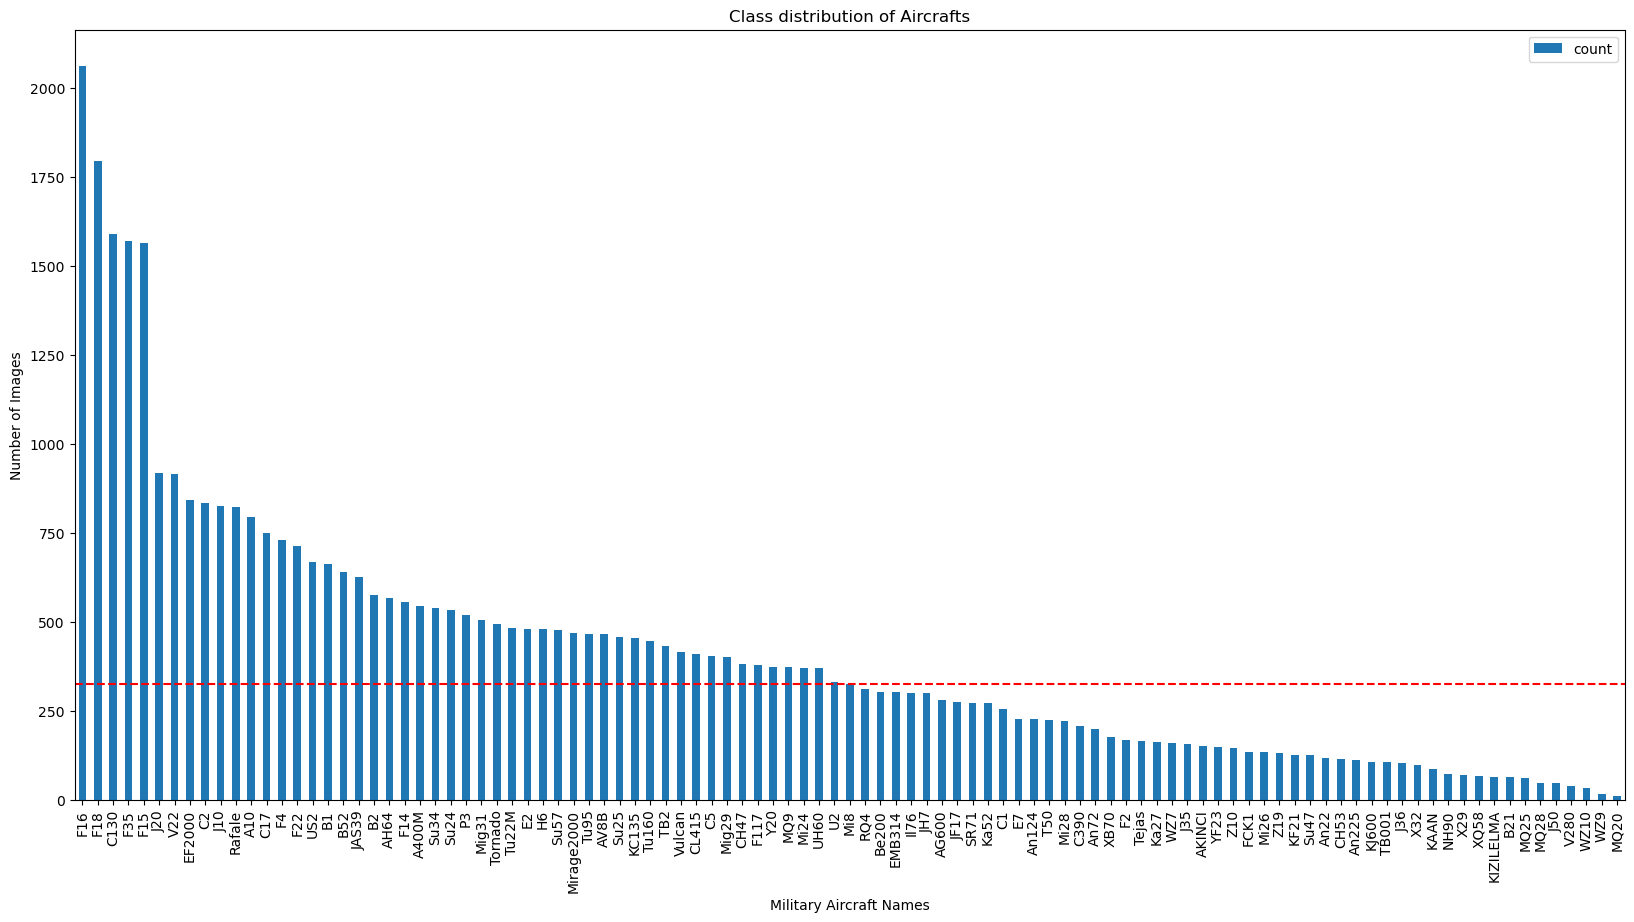

In [16]:
# Visualization of Category distribution of Aircrafts

df.plot.bar(figsize=(20, 10))
plt.title("Class distribution of Aircrafts")
plt.xlabel("Military Aircraft Names")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.axhline(y=np.median(df.values),
           linestyle="--",
           color="red")
plt.show();

# F16 is the dominant class (~2061 images) — the model will naturally lean toward predicting F16 if you don't handle this
# The red median line sits around ~330 images
# Roughly half the classes are below the median — that tail on the right is long
# MQ20 at the far right is nearly invisible (~11 images)

In [17]:
# Making function to plot random 5 images of a class
# Carried forward from v1 — no changes needed

def show_class_images(class_name:str):
    """
    This function takes any class name and shows 5 random images of that Aircraft class
    """
    # Creating a Dataframe for the specific class
    class_df = aircraft_labels[aircraft_labels["label"] == class_name]
    
    # Taking random 5 filepaths of the class as list
    random_image_paths = class_df["filepath"].sample(n=5, random_state=42).to_list()
    
    # Ploting a figure with 1 row and 5 columns
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # figsize=(width, height)
    
    # Plot image in its own subplot
    for ax, path in zip(axes, random_image_paths):
        img = plt.imread(path)   # plt.imread(path) reads the image file and returns it as a numpy array of shape (height, width, channels). Channels is usually 3 for RGB.
        ax.imshow(img)
        ax.axis("off")
        ax.set_aspect("auto")   # tells matplotlib to adapts to any image shape
    
    # So that all image look nice and constant
    fig.suptitle(class_name)
    plt.tight_layout()  # It automatically adjusts spacing between subplots so they don't overlap or get cut off — titles, labels, images all stay clean.
    plt.show();

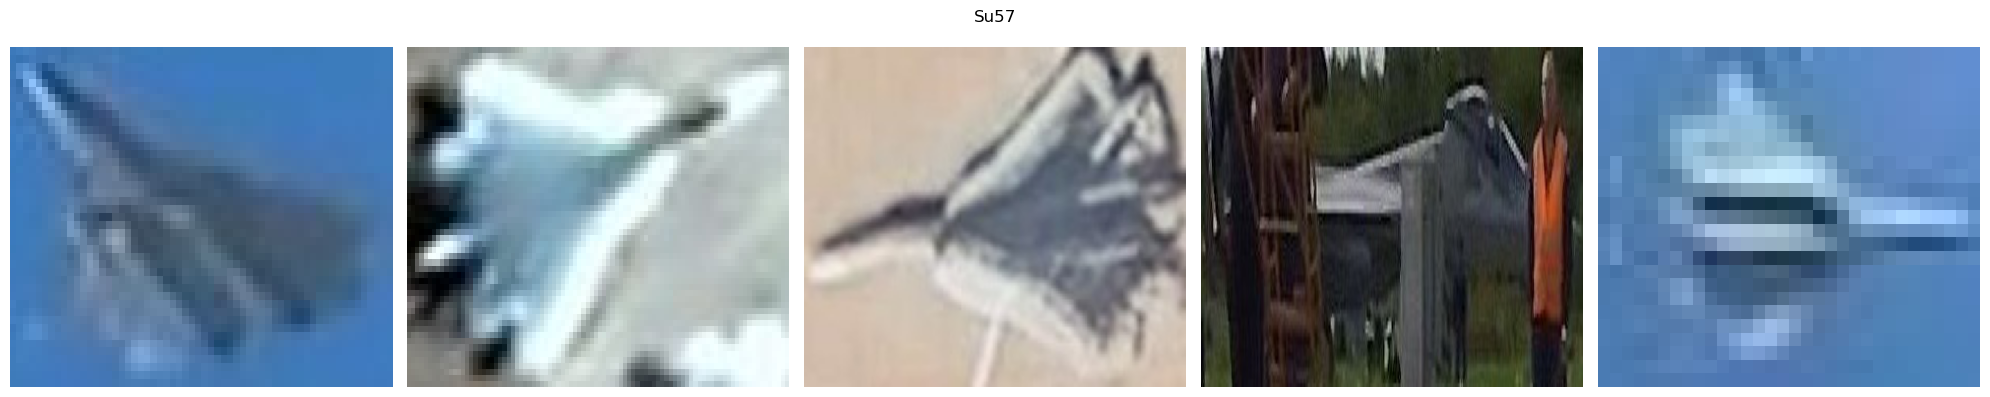

In [18]:
show_class_images("Su57")

> EDA was performed in full in `01_aircraft_classifier_v1.ipynb`. The insights below are carried forward - no need to rerun the analysis.

### **EDA Insights**

#### **Class Distribution**
- Dataset: 41,441 images across 101 aircraft classes
- Significant class imbalance exists
- **Top 5 classes (most images):** F16 (2061), F18 (1796), C130 (1590), F35 (1569), F15 (1564)
- **Bottom 5 classes (fewest images):** J50 (46), V280 (39), WZ10 (32), WZ9 (15), MQ20 (11)
- Median class size: ~330 images
- Imbalance risk: model may bias toward majority classes - addressed in v2 via class weighting

#### **Image Size Distribution**
- Heights range from 5px to 4912px → median 174px
- Widths range from 9px to 8074px → median 364px
- Sizes vary wildly across the dataset
- **Resize decision: (480, 480)** → EfficientNetV2-L native resolution, significantly above median for better fine-grained detail

#### **Visual Sample Check**
- Verified labels visually using random samples per class
- Images are wide and short in most cases (confirmed via shape check)

In [19]:
# Image shape constants — derived from 41,441 image analysis in v1
MAX_HEIGHT = 4912
MIN_HEIGHT = 5
MEDIAN_HEIGHT = 174

MAX_WIDTH = 8074
MIN_WIDTH = 9
MEDIAN_WIDTH = 364

# Resize target — EfficientNetV2-L native resolution
IMG_SIZE = (480, 480)

### **Constants**

- Image shape analysis was run once in v1 across all 41,441 images. Results hardcoded to avoid recomputation.
- Resize target updated to **(480, 480)** - EfficientNetV2-L's native resolution.
- v1 used (224, 224) for MobileNetV2 on a 4GB local GPU. v2 runs on Kaggle P100 (16GB) - no VRAM constraint.

> **Note on resizing:** 
> 
> Most images in this dataset are wide and short (median **364×174px**). 
> Resizing to **480×480** introduces some squeezing and stretching, but this is consistent 
> across all images and the model learns to handle it. The higher resolution preserves 
> significantly more detail than v1's **224×224**.

---

## **8. Data Pipeline (Image Loading + Preprocessing)**

The model cannot train on a CSV of filepaths. This section builds the pipeline that:
1. Encodes labels into one-hot vectors (101 classes) ✅
2. Loads images from disk using their filepaths ✅
3. Normalizes pixel values from [0, 255] to [0, 1] ✅
4. Resizes all images to **(480, 480) for EfficientNetV2-L** ✅
5. Batches and shuffles data using tf.data for efficient training ✅

### **Encoding Labels (One-Hot Encoding)**

Each label is a string (e.g. "F16"). The model outputs 101 probabilities - one per class.
To compare against that, each label must become a 101-length boolean array.

Approach:
- Get all 101 unique class names (sorted → consistent order) ✅
- For each image's label, compare against every class ✅
- Where it matches → 1, everywhere else → 0 ✅

In [20]:
# Getting all the names of the aircrafts

unique_labels = sorted(np.unique(aircraft_labels["label"]))
unique_labels = np.array(unique_labels)
unique_labels

array(['A10', 'A400M', 'AG600', 'AH64', 'AKINCI', 'AV8B', 'An124', 'An22',
       'An225', 'An72', 'B1', 'B2', 'B21', 'B52', 'Be200', 'C1', 'C130',
       'C17', 'C2', 'C390', 'C5', 'CH47', 'CH53', 'CL415', 'E2', 'E7',
       'EF2000', 'EMB314', 'F117', 'F14', 'F15', 'F16', 'F18', 'F2',
       'F22', 'F35', 'F4', 'FCK1', 'H6', 'Il76', 'J10', 'J20', 'J35',
       'J36', 'J50', 'JAS39', 'JF17', 'JH7', 'KAAN', 'KC135', 'KF21',
       'KIZILELMA', 'KJ600', 'Ka27', 'Ka52', 'MQ20', 'MQ25', 'MQ28',
       'MQ9', 'Mi24', 'Mi26', 'Mi28', 'Mi8', 'Mig29', 'Mig31',
       'Mirage2000', 'NH90', 'P3', 'RQ4', 'Rafale', 'SR71', 'Su24',
       'Su25', 'Su34', 'Su47', 'Su57', 'T50', 'TB001', 'TB2', 'Tejas',
       'Tornado', 'Tu160', 'Tu22M', 'Tu95', 'U2', 'UH60', 'US2', 'V22',
       'V280', 'Vulcan', 'WZ10', 'WZ7', 'WZ9', 'X29', 'X32', 'XB70',
       'XQ58', 'Y20', 'YF23', 'Z10', 'Z19'], dtype='<U10')

In [21]:
# Function to convert a single label string into a one-hot encoded array

def label_to_encoded_array(label:str):
    """
    Convert the label of the aircraft into a one-hot encoded array of length 101.
    Each value in the 101-length array represents one aircraft class.
    1 -> True
    0 -> False
    """

    encoded_label = (unique_labels == str(label)).astype(int)
    return encoded_label

In [22]:
def encode_labels(dataframe):
    """
    One-hot encodes the label column into a 101-length array.
    Original string labels are replaced with encoded arrays.
    
    Args:
        dataframe: train, val, or test dataframe with a 'label' column
    Returns:
        dataframe with 'label' column replaced by one-hot encoded arrays
    """
    dataframe["encoded_label"] = dataframe["label"].map(label_to_encoded_array)
    dataframe.drop(columns="label", inplace=True)
    dataframe.rename(columns={"encoded_label": "label"}, inplace=True)
    return dataframe

In [23]:
# Encoding the string labels to one-hot encoded labels in all 3 datasets

# Training data
train_data_df = encode_labels(train_data_df)

# Validation data
val_data_df = encode_labels(val_data_df)

# Testing data
test_data_df = encode_labels(test_data_df)

In [24]:
train_data_df.head()

,filepath,label
0,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [25]:
val_data_df.head()

,filepath,label
0,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [26]:
train_data_df.head()

,filepath,label
0,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


**Now we have encoded all the labels in to one-hot encoded arrays, which can be understood by our model.**

Now let's load and preprocess our images

### **Loading and Preprocessing Images**

Each image must be:
- Loaded from disk using its filepath
- Decoded into a tensor (RGB)
- Resized to **(480, 480)** → EfficientNetV2-L input requirement
- Normalized from [0, 255] to [0, 1] → helps the model train faster and more stably

#### **Image Loading**
- `tf.io.read_file(filepath)` -- reads raw bytes from disk, stays inside TF
- `tf.image.decode_jpeg(raw, channels=3)` -- decodes bytes into RGB tensor
- Must use TF-native functions (not `plt.imread`) so the pipeline can run efficiently at scale

**Why not plt.imread + tf.constant?**
- plt.imread is a Python operation -- TF cannot include it in an automated pipeline
- tf.constant just wraps existing memory -- it does not read files
- TF-native reading stays on the assembly line -- faster, parallelizable, pipeline-compatible

In [27]:
# Define the image size
# IMG_SIZE is already defined above as (480, 480)

# Create a function to preprocess the image
def process_image(image_path:str, image_size=IMG_SIZE):
    """
    Load and preprocess a single image from disk.
    - Reads raw bytes from the filepath
    - Decodes into an RGB tensor
    - Resizes to the target image size
    - Normalizes pixel values to [0, 1]

    Args:
        image_path: Path to the image file (string)
        image_size: Target image size

    Returns:
        Preprocessed image tensor
    """

    # Read the image as raw bytes from the filepath
    image = tf.io.read_file(image_path)

    # Decode into an RGB tensor
    image = tf.image.decode_jpeg(image, channels=3)

    # Convert pixel values from 0-255 to 0-1
    image = tf.image.convert_image_dtype(image, tf.float32)

    # Resize the image to the desired shape
    image = tf.image.resize(image, image_size)

    return image

#### **Image Preprocessing Function** - `process_image()`
- Takes a single filepath string as input
- `tf.io.read_file()` → reads raw bytes from disk
- `tf.image.decode_jpeg(channels=3)` → decodes into RGB tensor
- `tf.image.convert_image_dtype(tf.float32)` → normalizes pixels from [0, 255] to [0, 1] (must run before resize → resize converts to float32 internally, which breaks normalization)
- `tf.image.resize()` → resizes to (480, 480)
- Returns a single tensor of shape (480, 480, 3)

In [28]:
# Test process_image on a single image
test_image = process_image(aircraft_labels["filepath"][0])
print(test_image.shape)
print(test_image.dtype)
print(test_image)
print()
print(test_image.numpy().min(), test_image.numpy().max())

(480, 480, 3)
<dtype: 'float32'>
tf.Tensor(
[[[0.55265206 0.55265206 0.55265206]
  [0.558863   0.558863   0.558863  ]
  [0.560351   0.560351   0.560351  ]
  ...
  [0.48246655 0.47070184 0.43540773]
  [0.47451556 0.46275085 0.42745674]
  [0.48814717 0.47638246 0.44108835]]

 [[0.5476798  0.5476798  0.5476798 ]
  [0.5529412  0.5529412  0.5529412 ]
  [0.5524592  0.5524592  0.5524592 ]
  ...
  [0.4927184  0.4809537  0.44565958]
  [0.49097168 0.47920698 0.44391286]
  [0.49296573 0.48120102 0.4459069 ]]

 [[0.54191214 0.54191214 0.54191214]
  [0.5476307  0.5476307  0.5476307 ]
  [0.5538825  0.5538825  0.5538825 ]
  ...
  [0.4895932  0.4778285  0.4425344 ]
  [0.48458046 0.47281575 0.43752164]
  [0.47757387 0.46580917 0.43051505]]

 ...

 [[0.52402556 0.53579026 0.56185204]
  [0.5453639  0.5571633  0.5832425 ]
  [0.559843   0.5762239  0.6094342 ]
  ...
  [0.2368011  0.24072267 0.22111483]
  [0.2358906  0.24373373 0.22412589]
  [0.2406049  0.24844804 0.2288402 ]]

 [[0.5696457  0.5791064  0.599

- `process_image()` takes a single filepath and returns a preprocessed tensor
- Order matters: normalize before resize → resize converts to float32 internally
- Output: shape (480, 480, 3), dtype float32, pixel values in [0, 1]

### **Building the tf.data Pipeline**

`tf.data.Dataset` is a lazy conveyor belt → loads images on demand, one batch at a time.
Never loads all 41,000 images into memory at once.

Pipeline steps:
1. `from_tensor_slices()` → pairs filepaths with encoded labels
2. `shuffle()` → randomizes order so the model doesn't memorize sequence (training only)
3. `map()` → runs `process_image()` on each filepath, converting it to a tensor
4. `batch()` → groups into chunks of 32 before feeding to the GPU
5. `prefetch()` → loads the next batch while the GPU trains on the current one

Validation and test data skip the shuffle step → evaluation must be consistent across epochs.

In [29]:
len(train_data_df), len(val_data_df), len(test_data_df)

(31127, 7545, 2769)

In [30]:
train_data_df.head()

,filepath,label
0,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,/mnt/d/Eakem/Learning ML and DS/Project_ATAS/A...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [31]:
# Spliting dataframe into X and y

def get_X_and_y(dataframe):
    """
    Takes the DataFrame and split it into X and y labels.
    X --> filepath
    y --> numpy array of encoded label arrays 
    """
    X = dataframe["filepath"]
    y = np.stack(dataframe["label"])
    
    return X, y

In [32]:
# Initialising X and y for training dataset

X_train, y_train = get_X_and_y(train_data_df)
X_val, y_val     = get_X_and_y(val_data_df)
X_test, y_test   = get_X_and_y(test_data_df)

In [33]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(31127,) (31127, 101)
(7545,) (7545, 101)
(2769,) (2769, 101)


In [34]:
X_train[0], y_train[0]

('/mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data/crop/A10/00c09f406d31a0cd9402862fbd26d930_0.jpg',
 array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

### **Creating tf.data Batches**

A function that turns X (filepaths) and y (encoded labels) into batched tf.data pipelines.

**Three cases:**
1. **Training data**: shuffle then batch
2. **Validation data**: batch only (no shuffle)
3. **Test data**: no labels, batch only

In [35]:
# Simple function to return the tuple of (Tensor images, Encoded labels)

def image_label_together(image_path, label):
    """
    Take the image path and  associated encoded label as input,
    processes image into tensor and return the tuple (image, label)
    """
    image = process_image(image_path)
    return (image, label)

In [36]:
BATCH_SIZE = 32

def create_data_batches(X, y=None,
                        batch_size=BATCH_SIZE,
                        valid_data=False, test_data=False):
    """
    Create batches of data out of processed image (X) and label (y) pairs.
    Shuffles the data if it's training data but doesn't shuffle validation and test data.
    Also accepts test data as input (with no labels).
    
    Args:
        X: array of filepaths
        y: array of encoded labels (None for test data)
        batch_size: number of images per batch (default 32)
        valid_data: set True for validation data
        test_data: set True for test data (no labels)
    Returns:
        Batched tf.data.Dataset 
    """
    
    # Test data — no labels, just preprocess images and batch
    if test_data:
        print("Creating Testing data batches...")
        data = tf.data.Dataset.from_tensor_slices(X)        # no labels for test data
        data = data.map(process_image)                       # load and preprocess each image
        data_batches = data.batch(batch_size)                # group into batches
        return data_batches
    
    # Validation data — has labels but no shuffling (consistent evaluation each epoch)
    elif valid_data:
        print("Creating Validation data batches...")
        data = tf.data.Dataset.from_tensor_slices((X, y))   # pair filepaths with labels
        data = data.map(image_label_together)                # load image + keep label
        data_batches = data.batch(batch_size)                # no shuffle — consistent evaluation
        return data_batches
    
    # Training data — shuffle first, then map and batch
    else:
        print("Creating Training data batches...")
        data = tf.data.Dataset.from_tensor_slices((X, y))   # pair filepaths with labels
        data = data.shuffle(buffer_size=len(X))              # shuffle filepaths before loading
        data = data.map(image_label_together)                # load image + keep label
        data_batches = data.batch(batch_size)                # group into batches
        return data_batches

In [37]:
# Create data batches from Training data
train_data = create_data_batches(X_train, y_train)
print(train_data)

# Create data batches from Validation data
val_data = create_data_batches(X_val, y_val, valid_data=True)
print(val_data)

# Create data batches from Training data
test_data = create_data_batches(X_test, test_data=True)
print(train_data)

Creating Training data batches...
<_BatchDataset element_spec=(TensorSpec(shape=(None, 480, 480, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.int64, name=None))>
Creating Validation data batches...
<_BatchDataset element_spec=(TensorSpec(shape=(None, 480, 480, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.int64, name=None))>
Creating Testing data batches...
<_BatchDataset element_spec=(TensorSpec(shape=(None, 480, 480, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.int64, name=None))>


- `(None, 480, 480, 3)` → images - `None` means batch size is flexible, 480×480×3 is correct
- `(None, 101)` → labels - 101 one-hot values per image
- `dtype=tf.float32` → images normalized ✅
- `dtype=tf.int64` → labels as integers ✅

### **tf.data Pipeline**

**Key concepts:**
- `tf.data.Dataset` is lazy — loads images on demand, never all at once
- `from_tensor_slices((X, y))` pairs filepaths with labels and converts to tensors automatically
- No need for `tf.constant()` — `from_tensor_slices` handles conversion internally

**Pipeline behaviour by split:**
| Split | Labels | Shuffle | 
|---|---|---|
| Training | ✅ | ✅ shuffle before map (faster) |
| Validation | ✅ | ❌ consistent evaluation each epoch |
| Test | ❌ | ❌ inference only |

**Functions built:**
- `image_label_together(image_path, label)` — loads image and returns (image, label) tuple
- `create_data_batches(X, y, batch_size, valid_data, test_data)` — builds batched tf.data pipeline for any split

**Output shapes:**
- Images: `(None, 480, 480, 3)` — float32, normalized [0, 1]
- Labels: `(None, 101)` — int64, one-hot encoded
- Batch size: 32

---

**All components ready for model training:**
- ✅ Labels one-hot encoded (101 classes)
- ✅ Images loaded, resized to **(480, 480)**, normalized to [0, 1]
- ✅ Data split into train / val / test
- ✅ tf.data pipelines built and verified

---

In [38]:
# Carried forward from v1 — no changes needed

# Create a function for viewing images in a data batch
def show_n_images(images, labels, n):
    """Display a plot of 25 images and their labels from a data batch.

    Args:
    - images
    - labels
    - n : number of images to display depends on batch size. (Eg. 16, 32)
    Notice:
        Don't make n > BATCH_SIZE
    """
    
    # Setup figure
    plt.figure(figsize=(10,10))
    # Loop through 25 (For displaying 25 images)
    for i in range(n):
        # Create a subplot with 5 rows and 5 columns
        ax = plt.subplot(5, 5, i+1)
        # Display the image
        plt.imshow(images[i])
        # Add the image label as the title
        plt.title(unique_labels[labels[i].argmax()])
        # Turn of the grid lines
        plt.axis("off")
        
    plt.tight_layout()
    plt.show();


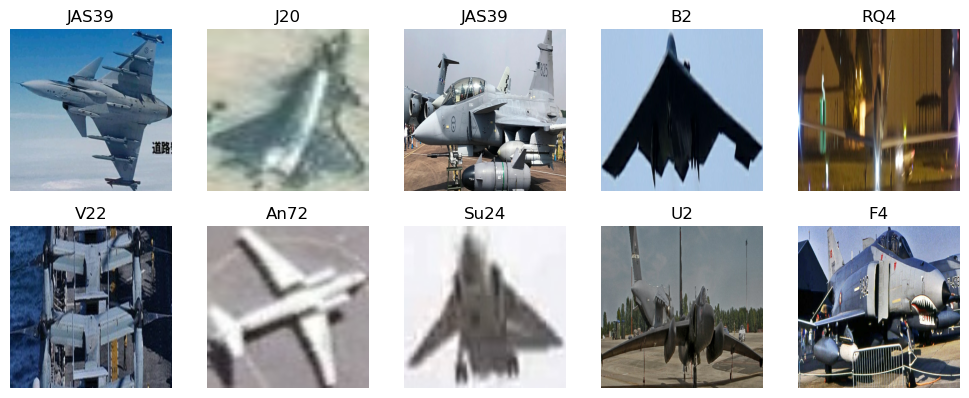

In [39]:
# Now let's visualize the data in training batch
train_images, train_labels = next(train_data.as_numpy_iterator()) # Convert the batch data to an iterator -> grab the next batch from the data that is 32
show_n_images(train_images, train_labels, n=10)

## **9. Build and Train Model**

### **Strategy: Transfer Learning**

Rather than training from scratch, we leverage [**EfficientNetV2-L**](https://www.kaggle.com/models/google/efficientnet-v2/TensorFlow2/imagenet21k-ft1k-l-feature-vector/2) — a CNN pre-trained on 21K ImageNet classes, fine-tuned on 1K.

**Workflow:**
- The base model extracts visual features (edges, textures, patterns) — frozen, not retrained
- We attach a custom **101-neuron Dense layer** (one per aircraft class) — this layer alone is trained first
- Then we unfreeze the top layers of the base model for fine-tuning

| Component | Role | Trainable? |
|-----------|------|-----------|
| EfficientNetV2-L base | Visual feature extraction | ❌ Frozen (phase 1) |
| Dense output layer (101 units) | Class prediction | ✅ Trained |

---

### **Model Selection: EfficientNetV2-L**

**Why EfficientNetV2-L?**
- **High capacity:** 118M parameters — built for fine-grained classification
- **Pretrained on ImageNet21k:** 21K classes → richer feature representations than ImageNet1k
- **Native resolution:** 480×480 — preserves more detail for visually similar aircraft
- **v1 ceiling:** MobileNetV2 plateaued at 64.56% — capacity and resolution were the bottleneck

**Configuration:**
- **Input shape:** `(480, 480, 3)` — normalized RGB
- **Output shape:** `(101,)` — one probability per aircraft class
- **Platform:** Kaggle P100 (16GB VRAM)

---

### **Model Architecture**
```
Input: (480, 480, 3) ──→ EfficientNetV2-L (frozen) ──→ Dense(101) ──→ Output: (101,)

RGB image           Feature extraction            Softmax      Aircraft probability
```

---

### **Why Not MobileNetV2?**

v1 used MobileNetV2 at 224×224 on a 4GB local GPU. It was the right choice then — lightweight, fast, fits in VRAM. But it hit a hard ceiling at 64.56% val accuracy. Fine-grained aircraft discrimination needs more capacity and resolution than MobileNetV2 can offer.

v2 runs on Kaggle P100 (16GB) — no VRAM constraint. EfficientNetV2-L is the natural upgrade.

---

### **Two Ways to Load a Pretrained Model**

#### **1. `tf.keras.applications`**

- Built into Keras. No extra install.
- Only ships with **ImageNet-1k** weights (1,000 classes).
- Docs: [Keras Applications](https://keras.io/api/applications/)

#### **2. TensorFlow Hub (`tensorflow_hub`)**

- External library. Loads models hosted on Kaggle/TF Hub.
- Gives access to **ImageNet-21k** weights (21,000 classes).
- Model: [EfficientNetV2-L on Kaggle](https://www.kaggle.com/models/google/efficientnet-v2/TensorFlow2/imagenet21k-ft1k-l-feature-vector/2)

---

#### **Why v2 Uses TF Hub**

`tf.keras.applications.EfficientNetV2L` exists — but only has ImageNet-1k weights.
The TF Hub version has ImageNet-21k weights → richer features → better ceiling for fine-grained classification.

That's the only reason. If we didn't need 21k weights, `tf.keras.applications` would be fine.

In [40]:
# IMG_SIZE already defined above as (480, 480)

# Model constants
INPUT_SHAPE  = (None, IMG_SIZE[0], IMG_SIZE[1], 3)  # (batch, height, width, channels)
OUTPUT_SHAPE = len(unique_labels)                   # 101 aircraft classes
MODEL_URL = "https://www.kaggle.com/models/google/efficientnet-v2/TensorFlow2/imagenet21k-ft1k-l-feature-vector/2"

In [41]:
# Create a function that builds an EfficientNetV2L transfer learning model

def create_model_efficientv2(input_shape=INPUT_SHAPE,
                             output_shape=OUTPUT_SHAPE,
                             model_url=MODEL_URL):
    """
    Creates an EfficientNetV2L transfer learning model for aircraft classification.
    Loads pretrained ImageNet-21k weights via TensorFlow Hub.

    Args:
        input_shape: Shape of input images
                     e.g. (None, 480, 480, 3)

        output_shape: Number of aircraft classes
                      e.g. 101

        model_url: TF Hub URL for pretrained EfficientNetV2L feature vector

    Returns:
        A compiled TensorFlow/Keras model
    """

    print("Building EfficientNetV2L transfer learning model...")
    print(f"Source: {model_url}")

    # Load EfficientNetV2L pretrained on ImageNet-21k via TF Hub
    # - input_shape[1:] removes batch dimension -> (480, 480, 3)
    # - feature-vector model already outputs pooled 1D embeddings
    # - trainable=False freezes pretrained backbone during head training
    base_model = hub.KerasLayer(
        model_url,
        input_shape=input_shape[1:],
        trainable=False
    )

    # Create model input layer
    inputs = tf.keras.Input(shape=input_shape[1:])

    # Extract image features using pretrained EfficientNetV2L backbone
    x = base_model(inputs)

    # Final classification layer
    # - one neuron per aircraft class
    # - softmax converts logits into probability distribution
    outputs = tf.keras.layers.Dense(
        units=output_shape,
        activation="softmax"
    )(x)

    # Build Functional API model
    model = tf.keras.Model(inputs, outputs)

    # Configure training setup
    model.compile(

        # Multi-class classification loss for one-hot encoded labels
        # label_smoothing reduces model overconfidence for better generalisation
        loss=tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=0.1
        ),

        # Adam optimizer adapts learning rates automatically
        optimizer=tf.keras.optimizers.Adam(),

        metrics=[
            # Exact class prediction accuracy
            "accuracy",

            # Checks whether true label appears in top 5 predictions
            tf.keras.metrics.TopKCategoricalAccuracy(
                k=5,
                name="top_5_accuracy"
            )
        ]
    )

    return model

### **Why v2 Has Fewer Parameters Than v1**

In MobileNetV2, three parameters did important jobs:
- `include_top=False` → removed the classification head
- `weights="imagenet"` → loaded pretrained weights
- `alpha=1.4` → controlled layer width

In EfficientNetV2L via TF Hub, **the URL does all three jobs automatically.**

---

#### **What the URL Does**

`imagenet21k-ft1k-l-feature-vector`

| Part | Meaning |
|---|---|
| `imagenet21k-ft1k` | Pretrained on ImageNet-21k, fine-tuned on ImageNet-1k |
| `l` | Large variant (EfficientNetV2-**L**) |
| `feature-vector` | Top already removed → outputs 1D vector directly |

No `include_top`, no `weights`, no `alpha` needed → the URL encodes all of it.

---

#### **Why No GlobalAveragePooling2D**

MobileNetV2 outputs a **3D feature map** → pooling converts it to a 1D vector → Dense layer classifies it.

EfficientNetV2L (`feature-vector`) outputs a **1D vector directly** → pooling is already done inside the model.

Adding `GlobalAveragePooling2D()` would cause a shape error. It expects 3D input but receives 1D.

---

### **Creating Callbacks**

Callbacks automate important tasks during training.

Used callbacks:
- **ModelCheckpoint** → saves best model
- **EarlyStopping** → stops bad training early
- **ReduceLROnPlateau** → lowers learning rate when learning slows
- **TensorBoard** → tracks training metrics

These improve:
- training stability
- monitoring
- model management

In [42]:
# Create a function to build a TensorBoard callback
def create_tensorboard_callback():
    # Create a log directory for TensorBoard logs
    logdir = os.path.join(str(LOG_DIR), datetime.datetime.now().strftime("%Y-%m-%d__%H-%M-%S"))

    # Make the directory if it does not exist
    os.makedirs(logdir, exist_ok=True)

    # Create the callback that writes logs into logdir
    return tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [43]:
# Creating all the callbacks for the model

# Folder to save the best trained model
os.makedirs(MODEL_DIR, exist_ok=True)

# Function to create all the callbacks
def create_callbacks():
    return [
        # TensorBoard callback - Saves training logs for visualization
        create_tensorboard_callback(),
        
        # EarlyStopping callback - Stops training if validation loss stops improving
        tf.keras.callbacks.EarlyStopping(
            monitor = "val_loss",        # Metric to monitor
            patience = 5,                # Wait 5 epochs before stopping
            restore_best_weights = True,  # Restore best model weights
            verbose=1                    # Print callback actions during training        
        ),
        
        #  # ReduceLROnPlateau callback - Lowers learning rate when training gets stuck 
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor = "val_loss",    # Metric to monitor
            factor = 0.2,            # Reduce LR by 80%
            patience = 2,            # Wait 2 epochs before reducing LR
            min_lr = 1e-7,            # Minimum learning rate
            verbose=1                # Print callback actions during training
        ),
        
        # ModelCheckpoint callback - Saves the best model during training
        tf.keras.callbacks.ModelCheckpoint(
            filepath = os.path.join(
                MODEL_DIR,
                f"efficientnetv2_best_model_{datetime.datetime.now().strftime('%Y-%m-%d__%H-%M-%S')}.keras"
            ),
            monitor = "val_loss",       # Save based on validation loss
            save_best_only=True,         # Save only the best model
            verbose=1                   # Print callback actions during training
        )
    ]

#### **Callback Patience Tuning (Full Dataset)**

Subset training used `patience=3` for both EarlyStopping and ReduceLROnPlateau.
Full dataset epochs take longer — model needs more time to improve.

| Callback | Before | After | Reason |
|---|---|---|---|
| EarlyStopping | patience=3 | patience=5 | More time before stopping |
| ReduceLROnPlateau | patience=3 | patience=2 | Reduce LR before stopping kicks in |

**Order of events:** LR reduces at epoch 2 of no improvement → still stuck by epoch 5 → stop.

---

### **Epochs & EarlyStopping**

#### **What is an epoch?**
**One epoch** = model sees every training image once. 
- Too few = underfitting. 
- Too many = overfitting. 
> Let val_loss decide when to stop.

#### **How many epochs to run?**
- Don't pick a fixed number. 
- Set `epochs=50`, let `EarlyStopping` handle it.

#### **What is patience?**
How many epochs you wait after val_loss stops improving before stopping. 
> Val_loss is noisy — patience absorbs that noise.

#### **How to pick patience?**
`patience ≈ 10–20% of expected total epochs`

| Expected Epochs | Patience |
|---|---|
| 10 | 2–3 |
| 20–30 | 5–7 |
| 50+ | 8–12 |

Noisy data (class imbalance, small dataset) → higher patience.

---

## **10. Training on Subset of Data**

Before training on the full dataset, a smaller subset of images is used first.

**Purpose**:

- verify training pipeline
- test callbacks
- check model learning
- validate predictions
- detect early issues quickly

This helps ensure the complete training setup works correctly before large-scale training.

In [44]:
# Checking train and validation data
train_data, val_data

(<_BatchDataset element_spec=(TensorSpec(shape=(None, 480, 480, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.int64, name=None))>,
 <_BatchDataset element_spec=(TensorSpec(shape=(None, 480, 480, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.int64, name=None))>)

In [45]:
# Defining the number of epochs for a model
# Creating a slider for epoch selection

import ipywidgets as widgets
from IPython.display import display

# Use existing NUM_EPOCHS or default to 100
NUM_EPOCHS = globals().get("NUM_EPOCHS", 100)

# Create slider widget
num_epoch_slider = widgets.IntSlider(
    value=NUM_EPOCHS,          # Default value
    min=10,                    # Minimum epochs
    max=100,                   # Maximum epochs
    step=1,                    # Step size
    description="NUM_EPOCHS",  # Slider label
    continuous_update=False    # Update only after releasing slider
)

# Create label to display current value
num_epoch_label = widgets.Label(
    value=f"NUM_EPOCHS = {NUM_EPOCHS}"
)

# Function runs when slider value changes
def on_num_epochs_change(change):
    global NUM_EPOCHS
    
    # Update global variable
    NUM_EPOCHS = change["new"]
    
    # Update label text
    num_epoch_label.value = f"NUM_EPOCHS = {NUM_EPOCHS}"

# Watch slider "value" changes
num_epoch_slider.observe(on_num_epochs_change, names="value")

# Display slider and label
display(num_epoch_slider, num_epoch_label)

IntSlider(value=100, continuous_update=False, description='NUM_EPOCHS', min=10)

Label(value='NUM_EPOCHS = 100')

In [46]:
# Function to train the EfficientNetV2L

def train_model(train_data_batches,
                val_data_batches,
                epochs=NUM_EPOCHS,
                class_weight=None):
    """
    Trains the EfficientNetV2L aircraft classification model.
    
    Args:
        train_data_batches:
            Training dataset batches.

        val_data_batches:
            Validation dataset batches.

        epochs:
            Number of training epochs.

        class_weight:
            Optional dictionary mapping class indexes to weights.
            Pass class_weight_dict to penalise rare class mistakes more.
            Default is None (no weighting applied).

    Returns:
        Trained TensorFlow/Keras model and training history.
    """

    # Instantiate TensorFlow model
    model = create_model_efficientv2(
        input_shape=INPUT_SHAPE,
        output_shape=OUTPUT_SHAPE,
        model_url=MODEL_URL
    )

    # Instantiate training callbacks
    callbacks = create_callbacks()

    # Train the model
    history = model.fit(
        x=train_data_batches,
        epochs=epochs,
        validation_data=val_data_batches,
        callbacks=callbacks,
        class_weight=class_weight  # None = no weighting, dict = weighted training
    )

    # Return trained model and training history
    return model, history

In [47]:
# Taking random sample rows from training and validation datasets
# Used for quick baseline experiments before full dataset training

train_subset = train_data_df.sample(
    n=1000,
    random_state=42  # Ensures same random subset every run
)

val_subset = val_data_df.sample(
    n=1000,
    random_state=42  # Ensures same random subset every run
)

# Extract image paths and one-hot encoded labels
X_train_subset, y_train_subset = get_X_and_y(train_subset)
X_val_subset, y_val_subset = get_X_and_y(val_subset)

# Create TensorFlow dataset batches
train_subset_data = create_data_batches(
    X_train_subset,
    y_train_subset
)

val_subset_data = create_data_batches(
    X_val_subset,
    y_val_subset
)

Creating Training data batches...
Creating Training data batches...


In [48]:
# # Training the model on subset of data
# subset_model, subset_history = train_model(
#     train_data_batches = train_subset_data,
#     val_data_batches = val_subset_data,
#     epochs=NUM_EPOCHS,
# )

In [49]:
# # Save the subset baseline model
# subset_model.save(
#    os.path.join(
#         MODEL_DIR,
#         "baseline_efficientnetv2_1000_model.keras"
#     ) 
# )

In [50]:
# import json

# # Convert TensorFlow float32 values into normal Python floats
# history_dict = {
#     key: [float(value) for value in values]
#     for key, values in subset_history.history.items()
# }

# # Save history as JSON
# with open("subset_history.json", "w") as f:
#     json.dump(history_dict, f)

**Now since we have our trained subset model. Let's load the model in the memory.**

In [51]:
# Load the EfficientNetV2-L model trained on 1000 images

# baseline_subset_model = tf.keras.models.load_model(
#     RELEASE_MODELS_DIR / "baseline_efficientnetv2_1000_model.keras",
#     custom_objects={"KerasLayer": hub.KerasLayer}
# )

In [52]:
# baseline_subset_model.summary()

# # Model: "model"
# # _________________________________________________________________
# #  Layer (type)                Output Shape              Param #   
# # =================================================================
# #  input_1 (InputLayer)        [(None, 480, 480, 3)]     0         
                                                                 
# #  keras_layer (KerasLayer)    (None, 1280)              117746848 
                                                                 
# #  dense (Dense)               (None, 101)               129381    
                                                                 
# # =================================================================
# # Total params: 117876229 (449.66 MB)
# # Trainable params: 129381 (505.39 KB)
# # Non-trainable params: 117746848 (449.17 MB)
# # _________________________________________________________________

### **Model Summary - EfficientNetV2-L Transfer Learning Model**

| Layer | Type | Output Shape | Role |
|---|---|---|---|
| input_1 | InputLayer | (None, 480, 480, 3) | Accepts raw image tensors |
| keras_layer | KerasLayer (TF Hub) | (None, 1280) | EfficientNetV2-L backbone extracts 1280 deep features per image, pretrained on ImageNet-21k |
| dense | Dense + Softmax | (None, 101) | Maps 1280 features to probability scores across 101 aircraft classes |

**Total parameters:** 117,876,229 (~450 MB)  
**Trainable:** 129,381 (Dense head only - backbone frozen)  
**Non-trainable:** 117,746,848 (EfficientNetV2-L backbone)

The backbone is frozen during baseline training, only the Dense head learns.
This is standard transfer learning: leverage ImageNet-21k knowledge, train only the classifier.

### **Checking the Tensorboard Logs**

The Tensorboard magic command (`%tensorboard`) will access the logs directory we created and visualize its contents.

In [53]:
import os
print(os.listdir(LOG_DIR))
print(LOG_DIR)

['2026-05-13 09:37:58', '2026-05-13 09:40:57', '2026-05-15 21:28:50', '2026-05-16 03:59:34', '2026-05-16 04:08:44', '2026-05-18__18-03-57', 'atas-classifier-v2.log']
/mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/logs


In [54]:
# logdir = LOG_DIR
# # For Kaggle or Colab: !tensorboard --logdir $logdir
# !tensorboard --logdir "$logdir" --port 6006

In [55]:
# To kill all running TensorBoard sessions
# !pkill -f tensorboard

### **Subset Training Analysis**

#### **EfficientNetV2-L · 1000-image subset · Frozen backbone**

---

#### **Observations**

| Metric | Result |
|---|---|
| Training accuracy | ~100% |
| Validation accuracy | ~35–36% |
| Overfitting | Severe — expected |
| Val stability | Stable (did not collapse) |
| Learning speed | Most improvement in first 10–15 epochs |

---

#### **What This Tells Us**

**Training hit ~100%** → the backbone memorized the small subset completely. Expected with only 1000 images and a model this powerful.

**Val accuracy plateaued at ~35–36%** → severe overfitting, but this is a sanity check on 1000 images, not a real training run. The number itself doesn't matter.

**Val performance stayed stable** → it didn't collapse or spike randomly. This confirms the pretrained ImageNet-21k features transfer effectively to aircraft classification. The backbone is doing real work.

---

#### **What Comes Next**

These four things will close the gap between train and val accuracy:

1. **Larger training data** → full dataset (~41k images) instead of 1000
2. **Data augmentation** → flips, rotations, zoom to reduce overfitting
3. **Fine-tuning** → unfreeze upper backbone layers to adapt to aircraft features
4. **Regularization** → label smoothing already in place; dropout if needed

---

> Subset training goal was pipeline validation, not performance. That goal is confirmed. ✅

---

## **11. Subset Predictions & Prediction Pipeline**

**Goal:**

Validate the prediction pipeline on the subset model for future reuse.

**Steps:**

1. Build predictions functions
2. Run predictions on subset model
3. Confirm pipeline works end to end

---

In [56]:
# Search for the saved subset model across environments
# Local: RELEASE_MODELS_DIR
# Kaggle: /kaggle/working/release_models or /kaggle/input if uploaded as a dataset
# Colab: RELEASE_MODELS_DIR after Drive is mounted

# def find_subset_model():
#     search_dirs = [RELEASE_MODELS_DIR]
#
#     if ENV == "kaggle":
#         for directory in Path("/kaggle/input").iterdir():
#             if directory.is_dir():
#                 search_dirs.append(directory)
#
#     for directory in search_dirs:
#         matches = sorted(directory.glob("baseline_efficientnetv2_1000_model*.keras"))
#         if matches:
#             print(f"Model found: {matches[-1]}")
#             return matches[-1]
#
#     raise FileNotFoundError(
#         f"No saved subset model found.\n"
#         f"Searched: {[str(directory) for directory in search_dirs]}\n"
#         f"Run the save step first or upload the model as a Kaggle dataset."
#     )
#
# # Load the model
# baseline_subset_model = tf.keras.models.load_model(
#     find_subset_model(),
#     custom_objects={"KerasLayer": hub.KerasLayer}
# )

In [57]:
import psutil
print(f"RAM used: {psutil.virtual_memory().percent}%")

RAM used: 28.1%


In [58]:
# # Run on Kaggle
# # Make predictions on the validation set (no used to train on)
# subset_predictions = baseline_subset_model.predict(val_subset_data,                                            verbose=1)

In [59]:
# Run on kaggle
# import numpy as np

# np.save("/kaggle/working/pred_probs.npy", subset_predictions)

In [60]:
# Load the saved subset predictions from the portable project predictions folder
subset_predictions_path = PREDICTIONS_DIR / "basline_subset_efficientv2l_predictions.npy"
subset_predictions = np.load(subset_predictions_path)


In [61]:
# 1000 rows with each having 101 probabilities
print(f"Shape of predictions: {subset_predictions.shape}")
print(f"Length each row predictions: {subset_predictions[0]}")

Shape of predictions: (1000, 101)
Length each row predictions: [4.7268328e-05 2.0023149e-03 1.3346901e-02 6.3339336e-04 3.4538975e-03
 5.5554916e-05 2.3438989e-03 4.5117312e-03 1.6705095e-03 1.9857723e-03
 7.4211778e-03 4.3503414e-03 4.5234798e-03 7.9781021e-05 1.0996969e-01
 3.4018676e-03 9.1256405e-04 7.0804176e-03 2.6272407e-03 5.7084474e-04
 4.7464515e-03 2.3417325e-04 5.9021893e-03 7.2187451e-03 4.8561655e-03
 4.1284557e-03 2.9431951e-05 1.5037331e-03 4.3774885e-03 5.9106882e-05
 1.0341776e-02 1.0942500e-03 3.5067313e-04 2.2737168e-04 1.1813432e-03
 9.2143338e-04 6.2110275e-04 1.8086309e-04 3.2038381e-04 1.5018127e-03
 3.2000698e-02 2.8228064e-03 8.9492844e-03 7.4200872e-03 3.1423571e-03
 6.5028681e-03 2.1263156e-02 4.4655514e-01 8.4250364e-03 4.8701372e-04
 2.1158231e-02 6.4765493e-04 3.8032422e-03 1.0590422e-03 1.0853339e-03
 4.5514512e-03 1.5731179e-03 2.8173428e-02 1.2444269e-03 6.9154645e-03
 7.0221163e-03 1.0666868e-03 4.5209564e-03 4.7625480e-03 4.3006282e-04
 5.0683911e-03

In [62]:
# For first predictions
index = 1
print(f"Predicted probabilities:\n {subset_predictions[index]}")
print(f"Max value (probability of predictions): {np.max(subset_predictions[index])}")
print(f"Sum: {np.sum(subset_predictions[index])}")
print(f"Max label index: {np.argmax(subset_predictions[index])}")
print(f"Predicted label: {unique_labels[np.argmax(subset_predictions[index])]}")

Predicted probabilities:
 [2.14653905e-04 3.53156179e-02 5.13905333e-03 1.04508756e-04
 4.49798815e-02 4.69683437e-03 2.15978874e-03 2.78914310e-02
 8.08912329e-03 2.69464292e-02 7.55113224e-03 1.26661337e-03
 5.08403732e-03 2.10488477e-04 4.30233069e-02 1.79528631e-03
 3.97495702e-02 5.84401749e-02 1.41288321e-02 6.22055680e-03
 1.03180096e-01 8.34391825e-03 1.19747175e-03 1.37658557e-03
 8.48701515e-04 6.83037424e-03 6.02616637e-04 1.52758113e-03
 3.89792398e-02 1.41037919e-04 3.12265547e-05 1.44804013e-03
 4.30786276e-05 3.96252144e-04 1.78322417e-03 8.31613317e-04
 4.31415356e-05 4.68557584e-04 2.58901436e-03 8.36882591e-02
 3.59880141e-05 2.01853109e-03 4.86780005e-03 1.46907317e-02
 3.23914271e-03 3.42094208e-05 4.78386553e-03 4.76899499e-04
 9.51893535e-03 6.28727721e-03 1.16240447e-02 1.12303356e-02
 1.14614051e-02 1.15647505e-03 4.10113530e-03 5.09934314e-03
 1.54837761e-02 1.92893052e-03 1.95180960e-02 1.42994092e-03
 9.91839543e-03 8.40514340e-03 1.27242412e-02 9.07459413e-0

In [63]:
unique_labels

array(['A10', 'A400M', 'AG600', 'AH64', 'AKINCI', 'AV8B', 'An124', 'An22',
       'An225', 'An72', 'B1', 'B2', 'B21', 'B52', 'Be200', 'C1', 'C130',
       'C17', 'C2', 'C390', 'C5', 'CH47', 'CH53', 'CL415', 'E2', 'E7',
       'EF2000', 'EMB314', 'F117', 'F14', 'F15', 'F16', 'F18', 'F2',
       'F22', 'F35', 'F4', 'FCK1', 'H6', 'Il76', 'J10', 'J20', 'J35',
       'J36', 'J50', 'JAS39', 'JF17', 'JH7', 'KAAN', 'KC135', 'KF21',
       'KIZILELMA', 'KJ600', 'Ka27', 'Ka52', 'MQ20', 'MQ25', 'MQ28',
       'MQ9', 'Mi24', 'Mi26', 'Mi28', 'Mi8', 'Mig29', 'Mig31',
       'Mirage2000', 'NH90', 'P3', 'RQ4', 'Rafale', 'SR71', 'Su24',
       'Su25', 'Su34', 'Su47', 'Su57', 'T50', 'TB001', 'TB2', 'Tejas',
       'Tornado', 'Tu160', 'Tu22M', 'Tu95', 'U2', 'UH60', 'US2', 'V22',
       'V280', 'Vulcan', 'WZ10', 'WZ7', 'WZ9', 'X29', 'X32', 'XB70',
       'XQ58', 'Y20', 'YF23', 'Z10', 'Z19'], dtype='<U10')

In [64]:
# Function to get the predicted label and visualize the predicted image

# Turn prediction probabilities into respective labels
def get_pred_label(prediction_probabilities):
    """
    Turn an array of prediction probabilities into a label.

    Args:
        prediction_probabilities: length-101 array of class probabilities
    """
    return unique_labels[np.argmax(prediction_probabilities)]

# Get the predicted label based on array of prediction probabilities
pred_label = get_pred_label(subset_predictions[2])
pred_label

'Tu95'

### **Unbatching Validation Data**

`val_data` is a batched `tf.data` pipeline. Images are grouped in batches of **32**. To compare predictions against true labels visually, we need:

- Individual images → to display
- Individual true labels → to compare against predicted labels

Unbatching flattens the pipeline back to one image at a time.

After unbatching we can iterate through and pull images + labels as separate arrays.

In [65]:
val_subset_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 480, 480, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.int64, name=None))>

In [66]:
# Create a function to unbatch a batched dataset

def unbatch_dataset(dataset):
    """
    Unbatch a batched tf.data dataset into separate image and label arrays.

    Args:
        dataset (tf.data.Dataset): Batched dataset of (image, label) tensor pairs.

    Returns:
        tuple:
            images (ndarray): Array of image tensors.
            labels (ndarray): Array of class names.
    """

    images = []
    labels = []

    # Loop through unbatched data
    for image, label in dataset.unbatch().as_numpy_iterator():
        images.append(image)
        labels.append(unique_labels[np.argmax(label)])

    return np.array(images), np.array(labels)


# Unbatch the validation data
val_subset_images, val_subset_labels = unbatch_dataset(val_subset_data)
val_subset_images[0], val_subset_labels[0]

(array([[[0.8907599 , 0.8005638 , 0.7456618 ],
         [0.8756251 , 0.785429  , 0.730527  ],
         [0.8835172 , 0.79332113, 0.7384191 ],
         ...,
         [0.86274517, 0.7725491 , 0.7019608 ],
         [0.8638603 , 0.77366424, 0.70307595],
         [0.846495  , 0.7562989 , 0.6857106 ]],
 
        [[0.8888143 , 0.7986182 , 0.7437162 ],
         [0.87403536, 0.7838393 , 0.72893727],
         [0.88280165, 0.7926056 , 0.73770356],
         ...,
         [0.86522067, 0.7750246 , 0.7044363 ],
         [0.86509806, 0.774902  , 0.7043137 ],
         [0.8484406 , 0.7582445 , 0.6876562 ]],
 
        [[0.88546246, 0.7952664 , 0.7403644 ],
         [0.8712966 , 0.7811005 , 0.7261985 ],
         [0.8815689 , 0.79137284, 0.7364708 ],
         ...,
         [0.8694854 , 0.7792893 , 0.708701  ],
         [0.8672304 , 0.77703434, 0.70644605],
         [0.85179245, 0.7615964 , 0.6910081 ]],
 
        ...,
 
        [[0.8119781 , 0.7531545 , 0.72570354],
         [0.81703186, 0.75820833, 0.73075

In [67]:
len(val_subset_images), val_subset_labels.shape

(1000, (1000,))

- `val_subset_images` → List of **1000** aircrafts images
- `val_subset_labels` → List of **1000** aircraft names

In [68]:
val_subset_labels[0]

'C130'

In [69]:
# For the first image, cross-check predicted and true validation labels
pred = get_pred_label(subset_predictions[0])
truth = get_pred_label(val_subset_labels[0])
pred, truth

('JH7', 'A10')


**Now we've got the:**

- Prediction labels (1000)
- Validation labels (1000)
- Validation images (1000)
  
Let's make some function to make these all a bit more vizualize.

**For the Function:**

- Takes an array of prediction probabilities and array of truth labels and an array of image and an integer.
- Convert the predictions probabilities to predicted label.
- Plot the predicted label, its's prediction probability, truth label and the target image on a single plot.

In [91]:

def plot_predictions(prediction_probabilities,
                     labels,
                     images,
                     n=1):
    """
    Plot a prediction with confidence score and ground truth label.

    Title color:
    - Blue  -> correct prediction
    - Coral -> incorrect prediction

    Args:
        prediction_probabilities (np.ndarray):
            Array of prediction probabilities of shape (N, num_classes)

        labels (list):
            List of true class labels

        images (list):
            List of image filepaths or processed image arrays

        n (int):
            Index of sample to visualize
    """

    # Get prediction probability, true label, and image
    pred_prob = prediction_probabilities[n]
    true_label = labels[n]
    image = images[n]

    # Process image only if input is a filepath
    if isinstance(image, str):
        image = process_image(image)

    # Convert tensor to numpy array if needed
    if tf.is_tensor(image):
        image = image.numpy()

    # Get predicted label
    pred_label = get_pred_label(pred_prob)

    # Set title color based on prediction correctness
    color = "blue" if pred_label == true_label else "coral"

    # Plot image
    plt.imshow(image)
    plt.axis("off")

    # Plot title
    plt.title(
        f"{pred_label} | {np.max(pred_prob)*100:.2f}% | True: {true_label}",
        color=color
    )

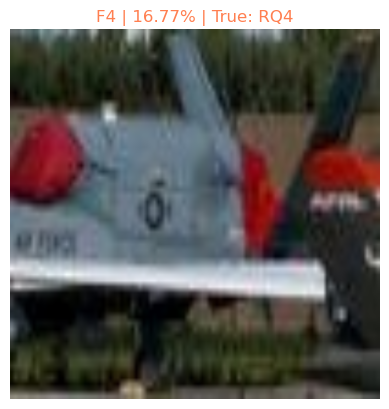

In [90]:
# Let's see the predictions 
plot_predictions(prediction_probabilities=subset_predictions,
                 labels=val_subset_labels,
                 images=val_subset_images,
                 n=5)

# Correct -> blue, wrong -> coral

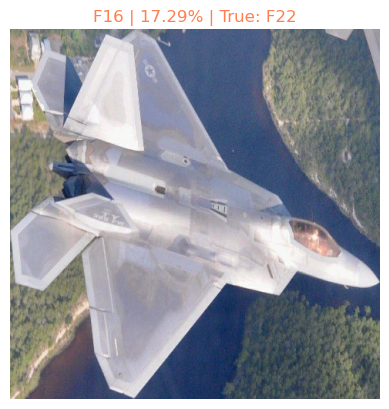

In [89]:
# Let's see another prediction
plot_predictions(prediction_probabilities=subset_predictions,
                 labels=val_subset_labels,
                 images=val_subset_images,
                 n=80)

# Correct -> blue, wrong -> coral

Now we've got the fucton to visualize our model's top confidence predictions, let's make a another function to view our model's **top 10 predictions**.

**The function will:**

- Take an input of prediction probabilities array, a ground truth array, and an integer.
- Find the predictive label using `get_pred_labels()`.
- **Find the Top 10:**
  - Prediction probabilities indexes
  - Prediction probabilities values
  - Prediction labels
- Plot the top 10 prediction probability and labels, colouring the true label **green**

In [92]:
def plot_top_10_pred_conf(prediction_probabilities, labels, n=1):
    """
    Plots a bar chart of the top 10 prediction confidences for a given sample.
    The bar for the true label is highlighted in green if it appears in the top 10.

    Args:
        - prediction_probabilities (np.ndarray): 2D array of prediction probabilities,
                                                shape (num_samples, num_classes).
        - labels (array-like): Array of true labels corresponding to each sample.
        - n (int, optional): Index of the sample to visualize. Defaults to 1.
    """
    pred_prob, true_label = prediction_probabilities[n], labels[n]
    
    # Get the prediction label
    pred_label = get_pred_label(pred_prob)

    # Get the top 10 prediction indexes
    top_10_pred_indexes = pred_prob.argsort()[-10:][::-1]    # indices sorted by value, LOW → HIGH and reverse → now HIGH → LOW
    
    # Get the top 10 prediction confidence values
    top_10_pred_values = pred_prob[top_10_pred_indexes]
    
    # Get the top 10 prediction labels
    top_10_pred_labels = unique_labels[top_10_pred_indexes]
    
    # Setup plot
    top_10_plot = plt.bar(x=np.arange(len(top_10_pred_labels)),
                          height=top_10_pred_values,
                          color="grey")
    plt.xticks(np.arange(len(top_10_pred_labels)),
               labels=top_10_pred_labels,
               rotation="vertical")
    plt.title(f"Predicted: {pred_label} | True: {true_label}")
    # Change the colour of true label -> green
    if np.isin(true_label, top_10_pred_labels):
        top_10_plot[np.argmax(top_10_pred_labels==true_label)].set_color("green")
    else:
        pass

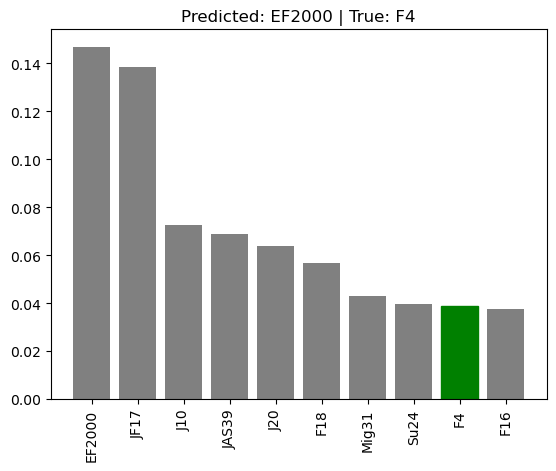

In [94]:
# VIsualizing the top 10 predictions
plot_top_10_pred_conf(prediction_probabilities=subset_predictions,
                      labels=val_subset_labels,
                      n=7)

**Now we've got some functions to help visualize our predictions and evaluate our model, let's check out few.**

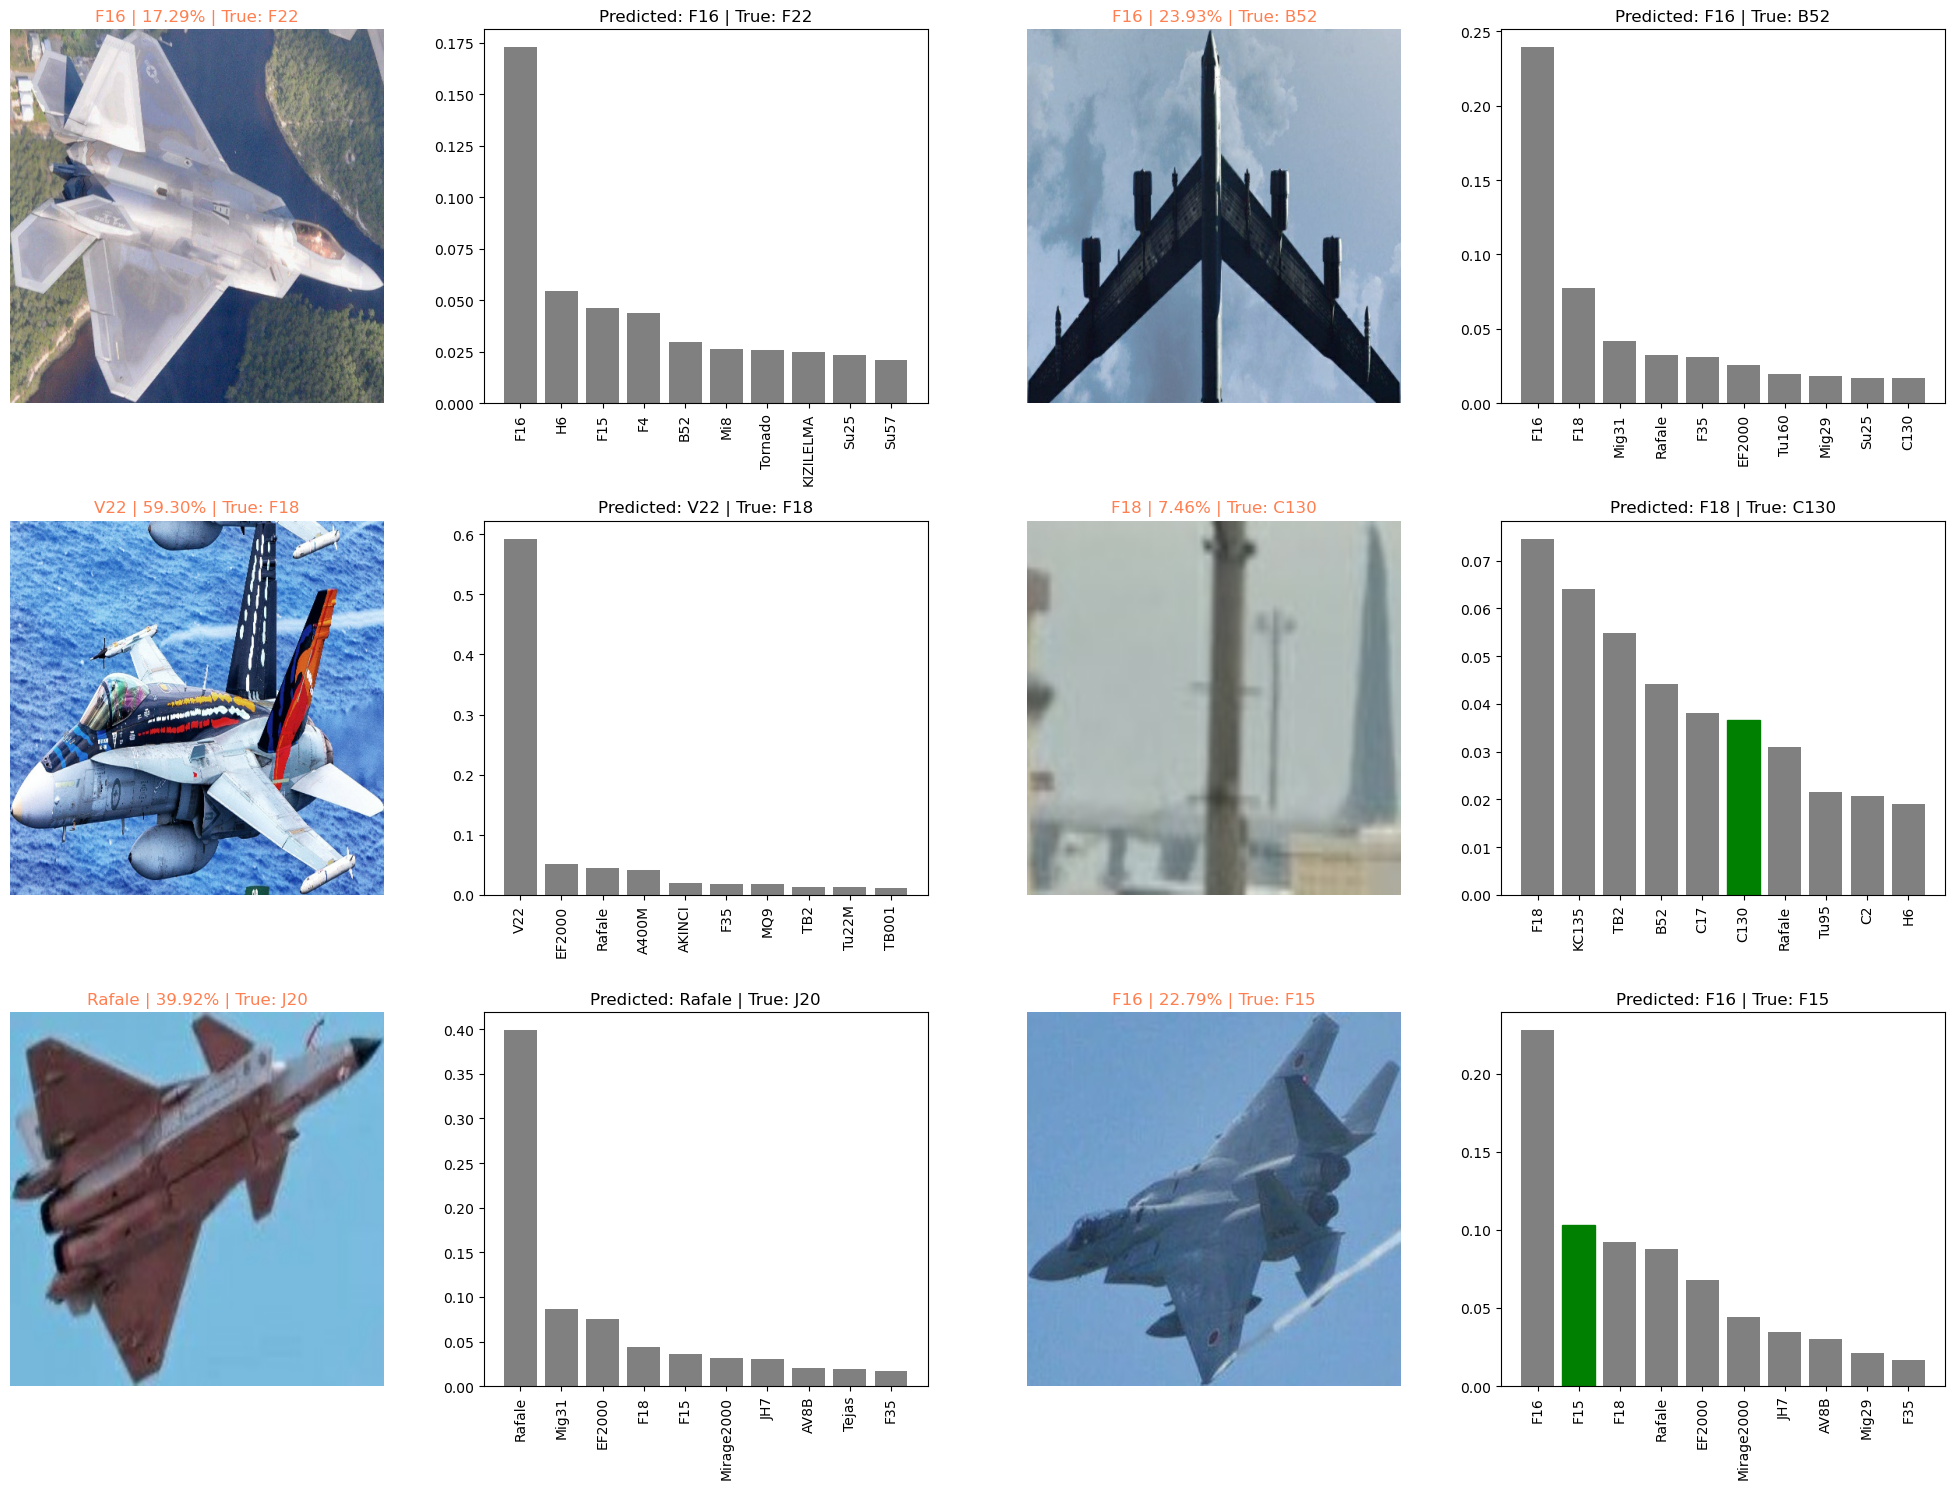

In [97]:
# Let's checkout out few predictions and their different value
i_multiplier = 80
num_rows = 3
num_cols = 2
num_images = num_rows*num_cols

# Plotting the figure
plt.figure(figsize=(10*num_cols, 5*num_rows))  # width -> cols, height -> rows

for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)   # (rows, columns, cell number)
    plot_predictions(prediction_probabilities=subset_predictions,
                     labels=val_subset_labels,
                     images=val_subset_images,
                     n=i+i_multiplier)  # n=i+i_multiplier is just the image index. Eg. Starting from dog #20, then #21, then #22 and so on
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_top_10_pred_conf(prediction_probabilities=subset_predictions,
                          labels=val_subset_labels,
                          n=i+i_multiplier)

# Everything looks nice 
plt.tight_layout()
plt.show()

## **12. Saving and reloading a trained model**

In [98]:

RELEASE_MODELS_DIR.exists()

True

In [99]:
# Function to save a model

def save_model(model, suffix="model"):
    """
    Saves a trained model inside release_models directory.

    Args:
        model:
            Trained TensorFlow model.

        suffix:
            Custom name for the saved model.

    Returns:
        Saved model path.
    """

    # Create release_models directory
    os.makedirs(RELEASE_MODELS_DIR, exist_ok=True)

    # Create timestamp
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d__%H-%M-%S")

    # Create final model path
    model_path = os.path.join(
        RELEASE_MODELS_DIR,
        f"{suffix}_{timestamp}.keras"
    )

    # Save the model
    print(f"Saving model to: {model_path}")
    model.save(model_path)

    print("Model saved successfully.")

    return model_path

# release_models/
# └── mobilenetv2_full_data_2026-05-12_08-15-44.keras

In [100]:
# Function to load a trained model

def load_model(model_path):
    """
    Loads a saved TensorFlow model.

    Args:
        model_path:
            Path to the saved model file.

    Returns:
        Loaded TensorFlow model.
    """

    print(f"Loading model from: {model_path}...")

    model = tf.keras.models.load_model(model_path)

    print("Model loaded successfully.")

    return model

In [ ]:
# # Evalute the laoded model
# baseline_subset_model.evaluate(val_subset_data)

# # Output:
# # 32/32 [==============================] - 30s 755ms/step - loss: 3.2159 - accuracy: 0.3580 - top_5_accuracy: 0.6290
# # [3.2159032821655273, 0.3580000102519989, 0.6290000081062317]

```python
baseline_subset_model.evaluate(val_subset_data)
[3.2159032821655273, 0.3580000102519989, 0.6290000081062317]
[loss,  accuracy,  top_5_accuracy]
```

- **Val Accuracy:** ~35%
- **Top-5 Accuracy:** ~62%
- **Random chance baseline:** ~1% (101 classes)

Model has learned something but needs full dataset, expected behaviour for 1000 images.

---

## **13. Training a big aircraft classifier 🛦**

### **13.1 Handling Class Imbalance Before Full Training**

#### **Why It Matters**

With 41k images across 101 classes, significant imbalance exists.
Common classes (F-16, F-18) have 1000+ images. Rare classes (J-50, WZ-10) have ~40.

A model trained on imbalanced data gets biased toward majority classes.
It learns to guess F-16 often because that guess gets rewarded more during training.
Rare classes get predicted almost never, even if overall accuracy looks okay.

---

#### **Three Approaches**

| Approach | What It Does | Downside |
|---|---|---|
| Oversampling | Duplicate/augment rare class images | Modifies data pipeline |
| Undersampling | Remove majority class images | Throws away real data |
| Class Weights | Penalise mistakes on rare classes more | Nothing → best fit here |

**Class weights chosen** → zero changes to the existing data pipeline.
Instead of changing how much data each class gets, we change how much each mistake costs.

---

#### **Computing Class Weights**

**Formula used internally:**
`weight = total_samples / (num_classes × samples_in_that_class)`

Rarer class → higher weight → mistakes on it cost more → model pays attention.

> Note: `compute_class_weight` needs integer labels, not one-hot encoded arrays.